# 🌧 Rain Tomorrow Prediction — XGBoost Classifier
### Weather Forecasting MLOps | Azamgarh ERA5 Dataset
---
**Objective:** Predict whether it will rain tomorrow (binary classification) using hourly ERA5 weather data.  
**Dataset:** Azamgarh, Uttar Pradesh — ERA5 Reanalysis (2021–2024)  
**Model:** XGBoost Classifier with Optuna tuning + MLflow tracking.

| Section | Description |
|---------|-------------|
| 1 | Environment Setup & Imports |
| 2 | MLflow Setup |
| 3 | Data Loading & Inspection |
| 4 | Hyperparameter Tuning — Optuna |
| 5 | Model Training with Cross-Validation |
| 6 | Evaluation & Metrics |
| 7 | Feature Importance |
| 8 | Threshold Tuning |
| 9 | Save Model & Log to MLflow |
| 10 | Inference Function |

## 1. Environment Setup & Imports

In [2]:
import os, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob


from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, accuracy_score, average_precision_score,
)
from sklearn.utils.class_weight import compute_sample_weight

import optuna
import mlflow
from optuna.integration import XGBoostPruningCallback
optuna.logging.set_verbosity(optuna.logging.WARNING)

from dotenv import load_dotenv
load_dotenv()

plt.rcParams.update({
    "figure.dpi"       : 120,
    "figure.facecolor" : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})
sns.set_palette("husl")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = sorted(glob.glob("../artifact/*/data_transformation/weather_final.csv"))[-1]
MODEL_DIR = "../models/xgboost"
MODEL_IMAGES_DIR = "../models/xgboost/image"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(MODEL_IMAGES_DIR, exist_ok=True)

print(f"Data  → {DATA_PATH}")
print(f"Model → {MODEL_DIR}")
print(f"Model Images→ {MODEL_IMAGES_DIR}")

Data  → ../artifact\10_08_2026_14_19_05\data_transformation\weather_final.csv
Model → ../models/xgboost
Model Images→ ../models/xgboost/image


## 2. MLflow Setup

In [3]:
# ── MLflow configuration ──
# Start MLflow server first: mlflow server --host 0.0.0.0 --port 5000
MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI") 
EXPERIMENT_NAME     = "weather_rain_xgboost"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"MLflow tracking URI : {MLFLOW_TRACKING_URI}")
print(f"Experiment          : {EXPERIMENT_NAME}")
print(f"UI                  : {MLFLOW_TRACKING_URI}/#/experiments")

2026/10/10 10:19:57 INFO mlflow.tracking.fluent: Experiment with name 'weather_rain_xgboost' does not exist. Creating a new experiment.


MLflow tracking URI : https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow
Experiment          : weather_rain_xgboost
UI                  : https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow/#/experiments


## 3. Data Loading & Inspection

In [4]:
df = pd.read_csv(DATA_PATH, parse_dates=["valid_time"])
df = df.sort_values("valid_time").reset_index(drop=True)

print(f"Shape      : {df.shape}")
print(f"Date range : {df['valid_time'].min()} → {df['valid_time'].max()}")
print(f"Missing    : {df.isnull().sum().sum()}")
df.head()

Shape      : (43800, 22)
Date range : 2021-01-02 05:30:00 → 2026-01-01 04:30:00
Missing    : 0


,valid_time,temperature,surface_pressure,total_cloud_cover,low_cloud_cover,medium_cloud_cover,high_cloud_cover,precipitation,humidity,wind_speed,...,month,day_of_week,hour_sin,hour_cos,month_sin,month_cos,temp_lag_1,temp_lag_24,temp_rolling_6,rain_tomorrow
0,2021-01-02 05:30:00,7.3191,1007.57,0.586762,0.0,0.0,0.586762,0.0,86.73,0.9666,...,1,5,0.965926,0.258819,0.5,0.866025,6.3538,6.6150,7.3103,0
1,2021-01-02 06:30:00,7.8957,1008.60,0.755707,0.0,0.0,0.755707,0.0,83.78,0.9099,...,1,5,1.000000,0.000000,0.5,0.866025,7.3191,6.1304,7.1736,0
2,2021-01-02 07:30:00,8.7751,1009.58,0.867371,0.0,0.0,0.867371,0.0,81.91,0.7471,...,1,5,0.965926,-0.258819,0.5,0.866025,7.8957,6.9004,7.3546,0
3,2021-01-02 08:30:00,9.1403,1010.22,0.919342,0.0,0.0,0.919342,0.0,81.13,0.4304,...,1,5,0.866025,-0.500000,0.5,0.866025,8.7751,7.8723,7.6300,0
4,2021-01-02 09:30:00,11.5016,1010.77,0.910004,0.0,0.0,0.910004,0.0,77.41,0.1777,...,1,5,0.707107,-0.707107,0.5,0.866025,9.1403,10.9252,8.4976,0


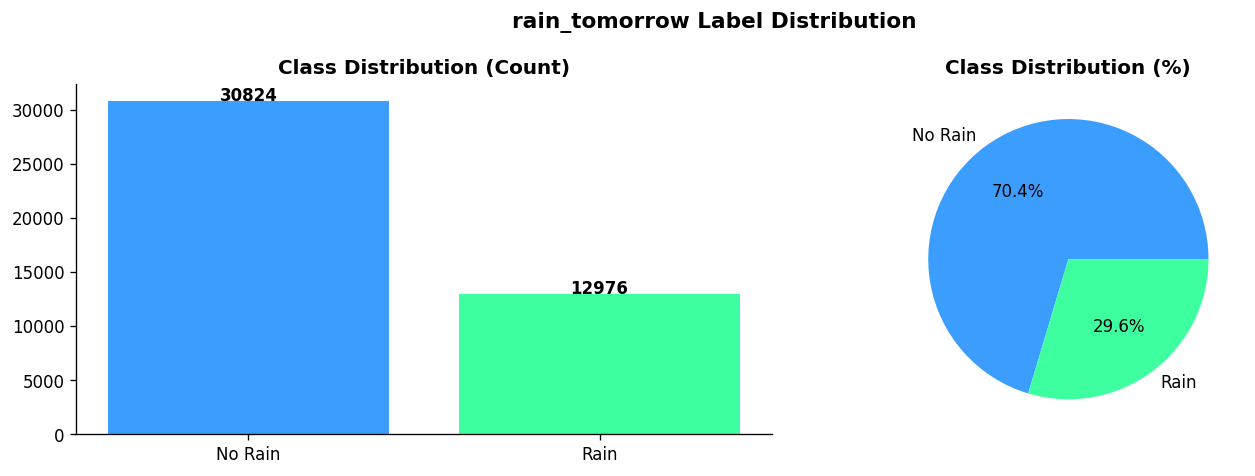

Rain=1 : 12,976 (29.6%)
Rain=0 : 30,824 (70.4%)
Imbalance ratio: 2.4:1


In [5]:
# ── Class distribution ──
rain_counts = df["rain_tomorrow"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(["No Rain", "Rain"], rain_counts.values, color=["#3b9eff", "#3dffa0"])
axes[0].set_title("Class Distribution (Count)", fontweight="bold")
for i, v in enumerate(rain_counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontweight="bold")

axes[1].pie(rain_counts.values, labels=["No Rain", "Rain"],
            autopct="%1.1f%%", colors=["#3b9eff", "#3dffa0"])
axes[1].set_title("Class Distribution (%)", fontweight="bold")
plt.suptitle("rain_tomorrow Label Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{MODEL_IMAGES_DIR}/class_distribution.png", bbox_inches="tight")
plt.show()

print(f"Rain=1 : {rain_counts[1]:,} ({100*rain_counts[1]/len(df):.1f}%)")
print(f"Rain=0 : {rain_counts[0]:,} ({100*rain_counts[0]/len(df):.1f}%)")
print(f"Imbalance ratio: {rain_counts[0]/rain_counts[1]:.1f}:1")

In [6]:
# ── Features & target ──
FEATURES = [
    "temperature",
    "surface_pressure",
    "total_cloud_cover",
    "low_cloud_cover",
    "medium_cloud_cover",
    "high_cloud_cover",
    "precipitation",
    "humidity",
    "wind_speed",
    "temp_rolling_6",
    "temp_lag_1",
    "temp_lag_24",
    "month",
]
TARGET = "rain_tomorrow"

X = df[FEATURES]
y = df[TARGET].astype(int)

# ── Time-based train/test split (80/20) ──
split_idx       = int(len(df) * 0.80)
X_train, X_test = X.iloc[:split_idx],  X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx],  y.iloc[split_idx:]

train_dates = df["valid_time"].iloc[:split_idx]
test_dates  = df["valid_time"].iloc[split_idx:]

print(f"Features : {len(FEATURES)}")
print(f"Train    : {len(X_train):,} rows  ({train_dates.min().date()} → {train_dates.max().date()})")
print(f"Test     : {len(X_test):,}  rows  ({test_dates.min().date()}  → {test_dates.max().date()})")

Features : 13
Train    : 35,040 rows  (2021-01-02 → 2025-01-01)
Test     : 8,760  rows  (2025-01-01  → 2026-01-01)


## 4. Hyperparameter Tuning — Optuna
Find best params first. Run once, then copy results to `params.yaml`.

In [7]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.3, log=True
        ),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),
        "min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 10
        ),
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 2.0),

        "use_label_encoder": False,
        "eval_metric": "logloss",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }

    # One MLflow run = one Optuna trial
    with mlflow.start_run(
        run_name=f"optuna_trial_{trial.number}",
        nested=True
    ):

        # Log Optuna trial information
        mlflow.set_tags({
            "stage": "hyperparameter_tuning",
            "model_type": "XGBoostClassifier",
            "tuner": "Optuna",
            "trial_number": trial.number,
        })

        mlflow.log_params(params)

        tscv = TimeSeriesSplit(n_splits=3)
        auc_scores = []

        for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):

            Xtr, Xval = X_train.iloc[tr_idx], X_train.iloc[val_idx]
            ytr, yval = y_train.iloc[tr_idx], y_train.iloc[val_idx]

            sw = compute_sample_weight("balanced", y=ytr)

            m = XGBClassifier(
                **params,
                early_stopping_rounds=20,
                callbacks=[
                    XGBoostPruningCallback(
                        trial,
                        "validation_0-logloss"
                    )
                ],
            )

            m.fit(
                Xtr,
                ytr,
                sample_weight=sw,
                eval_set=[(Xval, yval)],
                verbose=False,
            )

            auc = roc_auc_score(
                yval,
                m.predict_proba(Xval)[:, 1]
            )

            auc_scores.append(auc)

            # Log each fold's score
            mlflow.log_metric(f"fold_{fold + 1}_roc_auc", auc)

        # Average CV score
        mean_auc = np.mean(auc_scores)

        mlflow.log_metric("mean_cv_roc_auc", mean_auc)

        mlflow.log_metric("std_cv_roc_auc", np.std(auc_scores))

        return mean_auc


study = optuna.create_study(
    direction  = "maximize",
    study_name = "xgboost_rain_tuning",
    sampler    = optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner     = optuna.pruners.MedianPruner(n_warmup_steps=5),
)
study.optimize(objective, n_trials=20, show_progress_bar=True)

BEST_PARAMS = study.best_params
BEST_PARAMS.update({
    "use_label_encoder": False,
    "eval_metric"      : "logloss",
    "early_stopping_rounds": 20,
    "random_state"     : RANDOM_STATE,
    "n_jobs"           : -1,
})

  0%|          | 0/20 [00:00<?, ?it/s]

🏃 View run optuna_trial_0 at: https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow/#/experiments/3/runs/e46ff996a397481b97026a5c0aac794a
🧪 View experiment at: https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow/#/experiments/3


Best trial: 0. Best value: 0.942332:   5%|▌         | 1/20 [00:05<01:38,  5.18s/it]

🏃 View run optuna_trial_1 at: https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow/#/experiments/3/runs/1fd9f7088a7341ecb3126474c44afc0e
🧪 View experiment at: https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow/#/experiments/3


Best trial: 1. Best value: 0.947615:  10%|█         | 2/20 [00:09<01:26,  4.83s/it]

...

Best trial: 13. Best value: 0.948827:  90%|█████████ | 18/20 [05:21<00:47, 23.73s/it]

🏃 View run optuna_trial_18 at: https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow/#/experiments/3/runs/19f5d03d39ed4962a2c7f7b670b23330
🧪 View experiment at: https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow/#/experiments/3


Best trial: 13. Best value: 0.948827:  95%|█████████▌| 19/20 [05:37<00:21, 21.41s/it]

🏃 View run optuna_trial_19 at: https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow/#/experiments/3/runs/3c24e883c50049bf9d26f2ddf0b426cb
🧪 View experiment at: https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow/#/experiments/3


Best trial: 13. Best value: 0.948827: 100%|██████████| 20/20 [05:50<00:00, 17.54s/it]


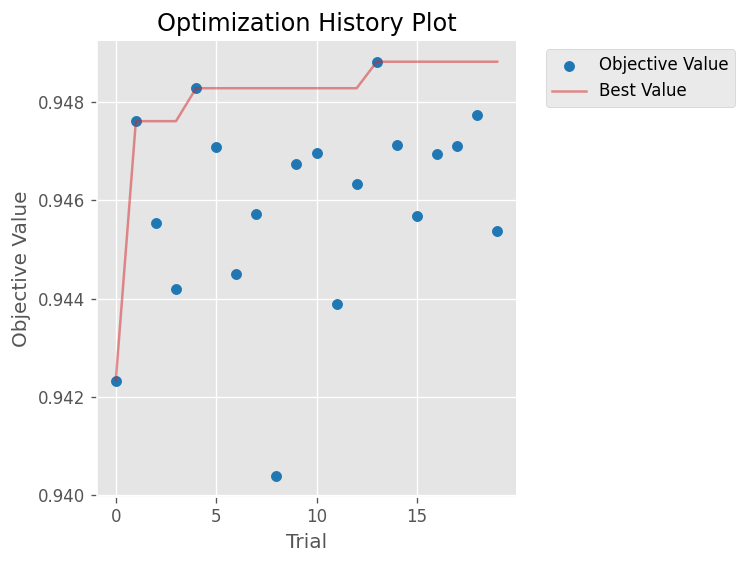

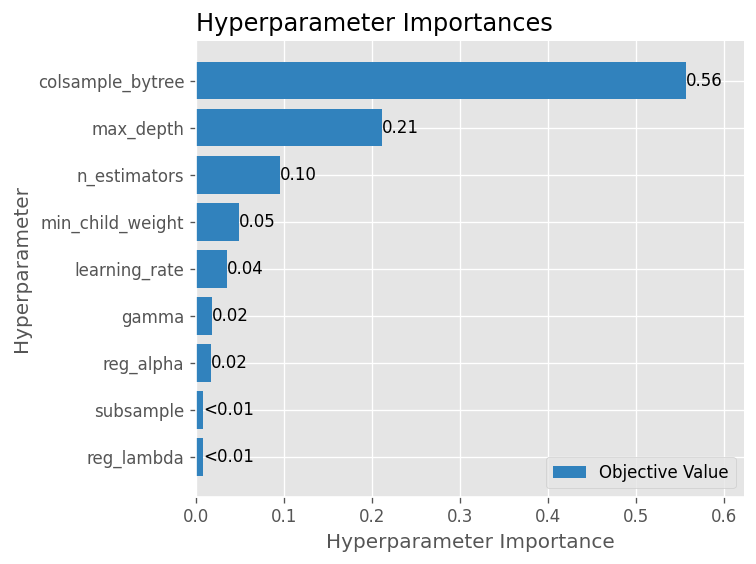

In [8]:
# ── Optuna visualizations ──
try:
    from optuna.visualization.matplotlib import (
        plot_optimization_history,
        plot_param_importances,
    )

    # Optimization history
    plot_optimization_history(study)
    plt.tight_layout()

    optimization_history_path = (
        f"{MODEL_IMAGES_DIR}/optuna_optimization_history.png"
    )

    plt.savefig(
        optimization_history_path,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    # Parameter importance
    plot_param_importances(study)
    plt.tight_layout()

    param_importance_path = (
        f"{MODEL_IMAGES_DIR}/optuna_param_importance.png"
    )

    plt.savefig(
        param_importance_path,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

except Exception as e:
    print(f"Plot skipped: {e}")

In [9]:
# ── Log Optuna study to MLflow ──
with mlflow.start_run(
    run_name="xgboost_optuna_best_trial"
) as optuna_run:

    mlflow.set_tags({
        "stage": "hyperparameter_tuning",
        "model_type": "XGBoostClassifier",
        "tuner": "Optuna",
        "study_name": "xgboost_rain_tuning",
    })

    # Best hyperparameters
    mlflow.log_params(study.best_params)

    # Best objective value
    mlflow.log_metric(
        "best_cv_roc_auc",
        study.best_value
    )

    # Number of trials
    mlflow.log_metric(
        "n_trials",
        len(study.trials)
    )

    # Log Optuna visualizations
    try:
        mlflow.log_artifact(
            f"{MODEL_IMAGES_DIR}/optuna_optimization_history.png"
        )

        mlflow.log_artifact(
            f"{MODEL_IMAGES_DIR}/optuna_param_importance.png"
        )

    except Exception as e:
        print(f"Could not log Optuna plots: {e}")

    optuna_run_id = optuna_run.info.run_id


print(f"Optuna run logged → {optuna_run_id}")

print(f"\n{'=' * 50}")
print("  COPY THESE TO params.yaml → xgboost section:")
print(f"{'=' * 50}")

for k, v in study.best_params.items():
    print(f"  {k:<22} : {v}")

print(f"{'=' * 50}")

🏃 View run xgboost_optuna_best_trial at: https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow/#/experiments/3/runs/7e7428a999cb495a945c8ee6c430fd39
🧪 View experiment at: https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow/#/experiments/3
Optuna run logged → 7e7428a999cb495a945c8ee6c430fd39

  COPY THESE TO params.yaml → xgboost section:
  n_estimators           : 304
  max_depth              : 3
  learning_rate          : 0.2000597712440253
  subsample              : 0.9090186258927353
  colsample_bytree       : 0.6300398129828485
  min_child_weight       : 1
  gamma                  : 0.4359601240080611
  reg_alpha              : 0.5984311571268364
  reg_lambda             : 1.5451562367416993


## 5. Model Training with Cross-Validation
Using best params from Optuna.

In [10]:
# ── 5-fold TimeSeriesSplit CV with best params ──
tscv      = TimeSeriesSplit(n_splits=5)
cv_scores = {"accuracy": [], "f1": [], "roc_auc": []}
cv_params = {k: v for k, v in BEST_PARAMS.items() if k != "early_stopping_rounds"}

print(f"{'Fold':<6} {'Train':>8} {'Val':>8} {'Accuracy':>10} {'F1':>8} {'ROC-AUC':>10}")
print("─" * 55)

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    Xtr, Xval = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    ytr, yval = y_train.iloc[tr_idx], y_train.iloc[val_idx]
    sw        = compute_sample_weight("balanced", y=ytr)

    m = XGBClassifier(**cv_params)
    m.fit(Xtr, ytr, sample_weight=sw, verbose=False)

    yp  = m.predict(Xval)
    ypp = m.predict_proba(Xval)[:, 1]

    cv_scores["accuracy"].append(accuracy_score(yval, yp))
    cv_scores["f1"].append(f1_score(yval, yp, zero_division=0))
    cv_scores["roc_auc"].append(roc_auc_score(yval, ypp))

    print(f"{fold:<6} {len(Xtr):>8,} {len(Xval):>8,} "
          f"{cv_scores['accuracy'][-1]:>10.4f} "
          f"{cv_scores['f1'][-1]:>8.4f} "
          f"{cv_scores['roc_auc'][-1]:>10.4f}")

print("─" * 55)
print(f"{'Mean':<6} {'':>8} {'':>8} "
      f"{np.mean(cv_scores['accuracy']):>10.4f} "
      f"{np.mean(cv_scores['f1']):>8.4f} "
      f"{np.mean(cv_scores['roc_auc']):>10.4f}")
print(f"{'Std':<6} {'':>8} {'':>8} "
      f"{np.std(cv_scores['accuracy']):>10.4f} "
      f"{np.std(cv_scores['f1']):>8.4f} "
      f"{np.std(cv_scores['roc_auc']):>10.4f}")

Fold      Train      Val   Accuracy       F1    ROC-AUC
───────────────────────────────────────────────────────
1         5,840    5,840     0.8801   0.6835     0.7980
2        11,680    5,840     0.8003   0.7753     0.9248
3        17,520    5,840     0.8784   0.7973     0.9359
4        23,360    5,840     0.9295   0.7883     0.9494
5        29,200    5,840     0.8639   0.8324     0.9405
───────────────────────────────────────────────────────
Mean                         0.8704   0.7754     0.9097
Std                          0.0415   0.0497     0.0564


In [11]:
# ── Final model on full train set ──
sample_weights = compute_sample_weight("balanced", y=y_train)

model = XGBClassifier(**BEST_PARAMS)
model.fit(
    X_train, y_train,
    sample_weight = sample_weights,
    eval_set      = [(X_test, y_test)],
    verbose       = 50,
)
print(f"Best iteration: {model.best_iteration}")

[0]	validation_0-logloss:0.58244
[50]	validation_0-logloss:0.25768
Best iteration: 30


## 6. Evaluation & Metrics

In [12]:
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_pred_prob)
ap  = average_precision_score(y_test, y_pred_prob)

print(f"Accuracy      : {acc:.4f}")
print(f"F1-Score      : {f1:.4f}")
print(f"ROC-AUC       : {auc:.4f}")
print(f"Avg Precision : {ap:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Rain", "Rain"], zero_division=0))

Accuracy      : 0.8916
F1-Score      : 0.8426
ROC-AUC       : 0.9647
Avg Precision : 0.9292

Classification Report:
              precision    recall  f1-score   support

     No Rain       0.96      0.88      0.92      5985
        Rain       0.78      0.92      0.84      2775

    accuracy                           0.89      8760
   macro avg       0.87      0.90      0.88      8760
weighted avg       0.90      0.89      0.89      8760



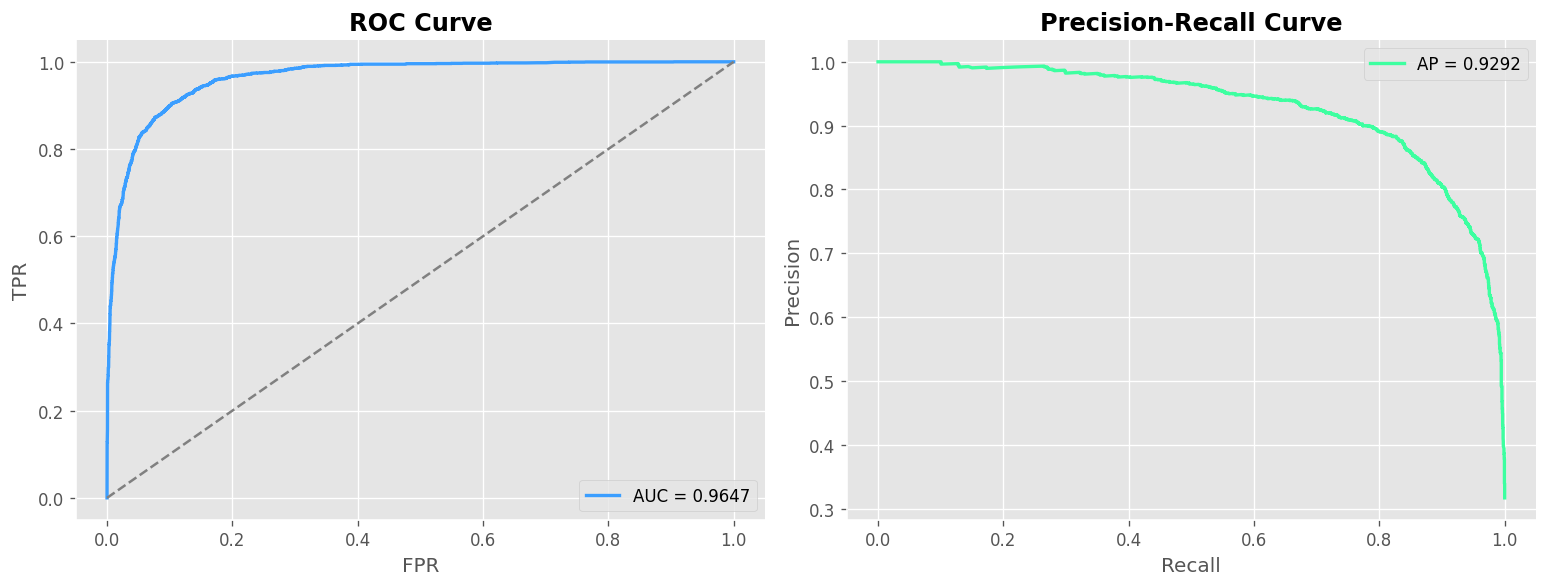

In [13]:
# ── ROC + PR curves ──
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
pre, rec, _ = precision_recall_curve(y_test, y_pred_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, color="#3b9eff", lw=2, label=f"AUC = {auc:.4f}")
axes[0].plot([0,1],[0,1],"--",color="gray")
axes[0].set_title("ROC Curve", fontweight="bold")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].legend()

axes[1].plot(rec, pre, color="#3dffa0", lw=2, label=f"AP = {ap:.4f}")
axes[1].set_title("Precision-Recall Curve", fontweight="bold")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{MODEL_IMAGES_DIR}/roc_pr_curves.png", bbox_inches="tight")
plt.show()

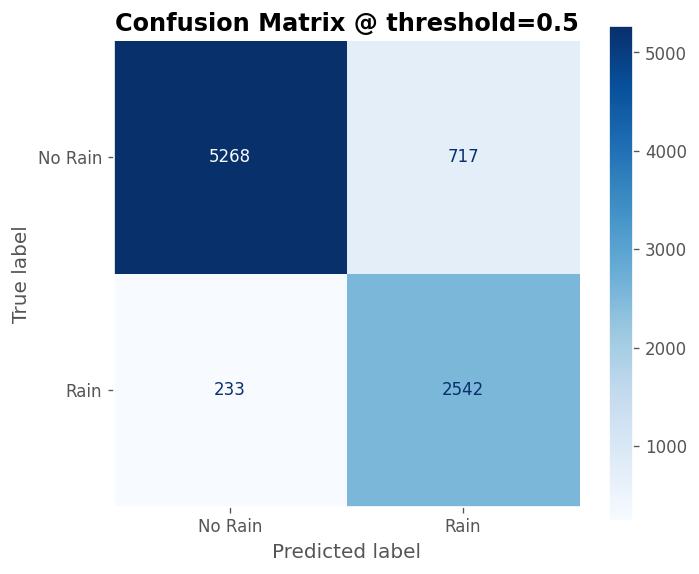

In [14]:
# ── Confusion matrix ──
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    cm,
    display_labels=["No Rain", "Rain"]
).plot(
    ax=ax,
    cmap="Blues"
)

ax.set_title(
    "Confusion Matrix @ threshold=0.5",
    fontweight="bold"
)

ax.grid(False)  # remove grid lines

plt.tight_layout()

plt.savefig(
    f"{MODEL_IMAGES_DIR}/confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

## 7. Feature Importance

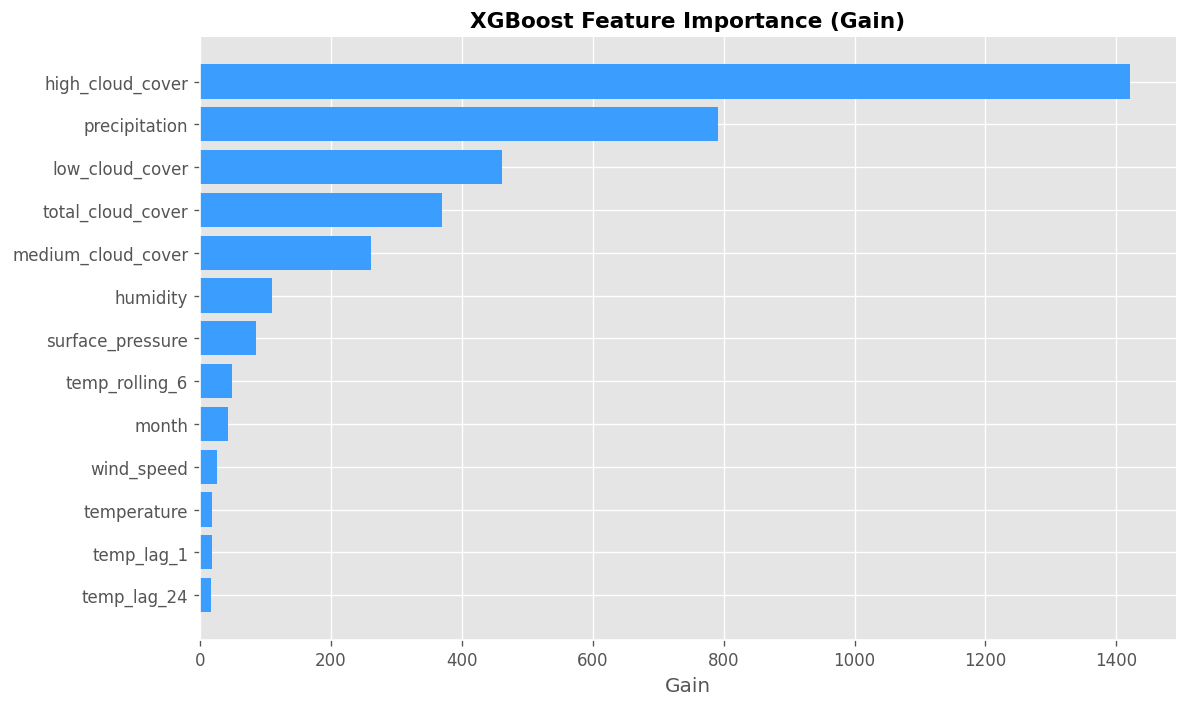


Feature                      Gain
───────────────────────────────────
high_cloud_cover        1420.0864
precipitation            790.9706
low_cloud_cover          460.8748
total_cloud_cover        369.5629
medium_cloud_cover       260.8799
humidity                 109.4350
surface_pressure          86.3893
temp_rolling_6            48.6454
month                     43.0432
wind_speed                26.6765
temperature               18.9069
temp_lag_1                17.9877
temp_lag_24               17.0088


In [15]:
importance_gain = model.get_booster().get_score(importance_type="gain")
importance_gain = dict(sorted(importance_gain.items(), key=lambda x: x[1], reverse=True))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    list(importance_gain.keys())[::-1],
    list(importance_gain.values())[::-1],
    color="#3b9eff",
)
ax.set_title("XGBoost Feature Importance (Gain)", fontweight="bold", fontsize=13)
ax.set_xlabel("Gain")
plt.tight_layout()
plt.savefig(f"{MODEL_IMAGES_DIR}/feature_importance.png", bbox_inches="tight")
plt.show()

print(f"\n{'Feature':<22} {'Gain':>10}")
print("─" * 35)
for feat, score in importance_gain.items():
    print(f"{feat:<22} {score:>10.4f}")

## 8. Threshold Tuning

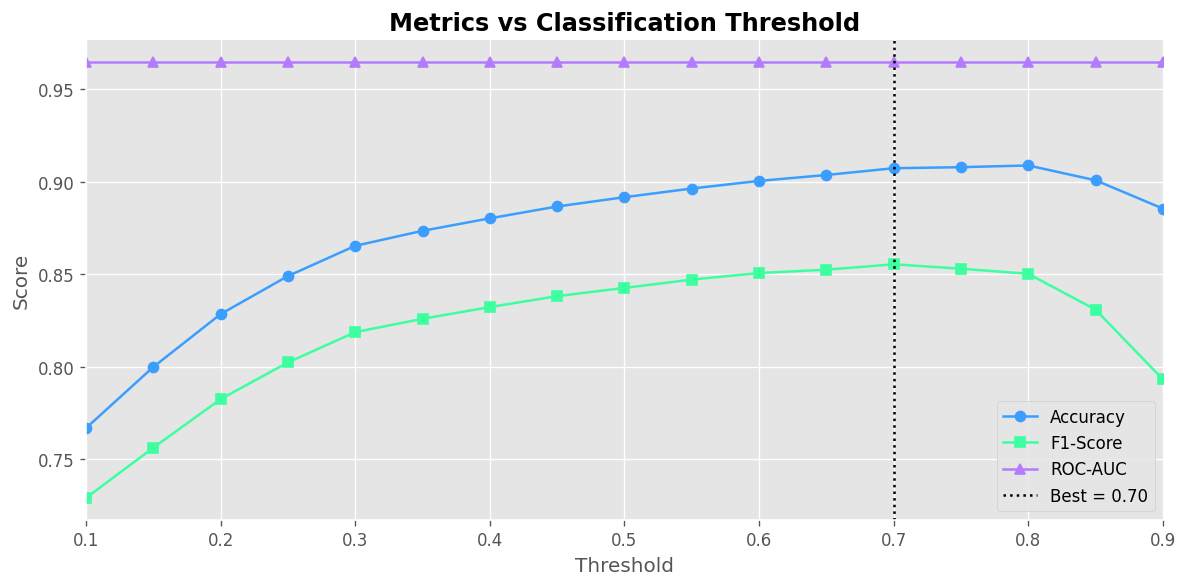

Best threshold : 0.7000000000000002
F1  tuned      : 0.8553  (was 0.8426 @ 0.5)
Acc tuned      : 0.9072  (was 0.8916 @ 0.5)


In [16]:
thresholds = np.arange(0.10, 0.91, 0.05)
accs, f1s, aucs = [], [], []

for thr in thresholds:
    yp = (y_pred_prob >= thr).astype(int)
    accs.append(accuracy_score(y_test, yp))
    f1s.append(f1_score(y_test, yp, zero_division=0))
    aucs.append(roc_auc_score(y_test, y_pred_prob))

best_thr = float(thresholds[np.argmax(f1s)])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, accs, label="Accuracy", marker="o", color="#3b9eff")
ax.plot(thresholds, f1s,  label="F1-Score", marker="s", color="#3dffa0")
ax.plot(thresholds, aucs, label="ROC-AUC",  marker="^", color="#b57bff")
ax.axvline(best_thr, color="black", linestyle=":", label=f"Best = {best_thr:.2f}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title("Metrics vs Classification Threshold", fontweight="bold")
ax.legend(); ax.set_xlim(0.1, 0.9)
plt.tight_layout()
plt.savefig(f"{MODEL_IMAGES_DIR}/threshold_tuning.png", bbox_inches="tight")
plt.show()

BEST_THRESHOLD = best_thr
y_pred_tuned   = (y_pred_prob >= BEST_THRESHOLD).astype(int)
f1_tuned       = f1_score(y_test, y_pred_tuned, zero_division=0)
acc_tuned      = accuracy_score(y_test, y_pred_tuned)

print(f"Best threshold : {BEST_THRESHOLD}")
print(f"F1  tuned      : {f1_tuned:.4f}  (was {f1:.4f} @ 0.5)")
print(f"Acc tuned      : {acc_tuned:.4f}  (was {acc:.4f} @ 0.5)")

## 9. Save Model & Log to MLflow

In [17]:
# ── Build metadata ──
meta = {
    "model"           : "XGBoostClassifier",
    "features"        : FEATURES,
    "target"          : TARGET,
    "best_threshold"  : BEST_THRESHOLD,
    "best_iteration"  : int(model.best_iteration),
    "train_rows"      : int(len(X_train)),
    "test_rows"       : int(len(X_test)),
    "hyperparameters" : {k: v for k, v in BEST_PARAMS.items()},
    "cv_results": {
        "mean_accuracy" : round(float(np.mean(cv_scores["accuracy"])), 4),
        "std_accuracy"  : round(float(np.std(cv_scores["accuracy"])),  4),
        "mean_f1"       : round(float(np.mean(cv_scores["f1"])),       4),
        "std_f1"        : round(float(np.std(cv_scores["f1"])),        4),
        "mean_roc_auc"  : round(float(np.mean(cv_scores["roc_auc"])),  4),
        "std_roc_auc"   : round(float(np.std(cv_scores["roc_auc"])),   4),
    },
    "roc_auc"         : round(float(auc),      4),
    "avg_precision"   : round(float(ap),       4),
    "metrics_at_0_5"  : {
        "accuracy" : round(float(acc), 4),
        "f1_score" : round(float(f1),  4),
    },
    "metrics_at_best_threshold": {
        "threshold": BEST_THRESHOLD,
        "accuracy" : round(float(acc_tuned), 4),
        "f1_score" : round(float(f1_tuned),  4),
    },
    "feature_importance_gain": {
        k: round(v, 4) for k, v in importance_gain.items()
    },
}

model_path = os.path.join(MODEL_DIR, "rain_model.json")
meta_path  = os.path.join(MODEL_DIR, "model_meta.json")
model.save_model(model_path)
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

print(f"Model saved → {model_path}")
print(f"Meta  saved → {meta_path}")

Model saved → ../models/xgboost\rain_model.json
Meta  saved → ../models/xgboost\model_meta.json


In [18]:
# ── Log final run to MLflow ──
with mlflow.start_run(run_name="xgboost_rain_final") as run:
    mlflow.set_tags({
        "model_type" : "XGBoostClassifier",
        "task"       : "rain_prediction",
        "dataset"    : "ERA5_Azamgarh",
        "stage"      : "final",
        "optuna_run" : optuna_run_id,
    })

    mlflow.log_params(BEST_PARAMS)
    mlflow.log_param("best_threshold", BEST_THRESHOLD)
    mlflow.log_param("train_rows",     len(X_train))
    mlflow.log_param("test_rows",      len(X_test))
    mlflow.log_param("n_features",     len(FEATURES))

    mlflow.log_metrics({
        "roc_auc"         : round(float(auc),        4),
        "avg_precision"   : round(float(ap),          4),
        "acc_at_0_5"      : round(float(acc),         4),
        "f1_at_0_5"       : round(float(f1),          4),
        "acc_tuned"       : round(float(acc_tuned),   4),
        "f1_tuned"        : round(float(f1_tuned),    4),
        "cv_mean_roc_auc" : round(float(np.mean(cv_scores["roc_auc"])), 4),
        "cv_std_roc_auc"  : round(float(np.std(cv_scores["roc_auc"])),  4),
        "cv_mean_f1"      : round(float(np.mean(cv_scores["f1"])),      4),
        "best_iteration"  : int(model.best_iteration),
    })

    for artifact in [
        model_path, meta_path,
        f"{MODEL_IMAGES_DIR}/roc_pr_curves.png",
        f"{MODEL_IMAGES_DIR}/confusion_matrix.png",
        f"{MODEL_IMAGES_DIR}/feature_importance.png",
        f"{MODEL_IMAGES_DIR}/threshold_tuning.png",
        f"{MODEL_IMAGES_DIR}/class_distribution.png",
        f"{MODEL_IMAGES_DIR}/optuna_results.png",
    ]:
        try:
            mlflow.log_artifact(artifact)
        except Exception:
            pass

    mlflow.xgboost.log_model(model, "xgboost_model")
    final_run_id = run.info.run_id

print(f"Final run logged → {final_run_id}")
print(f"View at → {MLFLOW_TRACKING_URI}/#/experiments")

2026/10/10 10:31:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run xgboost_rain_final at: https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow/#/experiments/3/runs/4210e52a9b4944bb856618473c5bd0dc
🧪 View experiment at: https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow/#/experiments/3
Final run logged → 4210e52a9b4944bb856618473c5bd0dc
View at → https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow/#/experiments


## 10. Inference Function

In [38]:
def predict_rain(input_dict: dict, threshold: float = BEST_THRESHOLD) -> dict:
    row  = pd.DataFrame([{feat: input_dict[feat] for feat in FEATURES}])
    prob = model.predict_proba(row)[0][1]

    if prob > 0.75:   confidence = "high (rain likely)"
    elif prob > 0.55: confidence = "medium"
    elif prob < 0.25: confidence = "high (no rain likely)"
    else:             confidence = "low (uncertain)"

    return {
        "rain_tomorrow"  : bool(prob >= threshold),
        "probability"    : round(float(prob), 4),
        "confidence"     : confidence,
        "threshold_used" : threshold,
    }


print("── Demo Predictions on Test Samples ──")
print(f"{'#':<4} {'Prob':>6} {'Predicted':>12} {'Actual':>10} {'Match':>6}")
print("─" * 45)
for i in range(5):
    sample = X_test.iloc[i].to_dict()
    result = predict_rain(sample)
    actual = int(y_test.iloc[i])
    pred   = "Rain" if result["rain_tomorrow"] else "No Rain"
    act    = "Rain" if actual else "No Rain"
    match  = "✅" if pred == act else "❌"
    print(f"{i+1:<4} {result['probability']:>6.4f} {pred:>12} {act:>10} {match:>6}")

── Demo Predictions on Test Samples ──
#      Prob    Predicted     Actual  Match
─────────────────────────────────────────────
1    0.1287      No Rain    No Rain      ✅
2    0.1474      No Rain    No Rain      ✅
3    0.0315      No Rain    No Rain      ✅
4    0.0278      No Rain    No Rain      ✅
5    0.0309      No Rain    No Rain      ✅


In [39]:
print("\n" + "═"*55)
print("  EXPERIMENT COMPLETE — SUMMARY")
print("═"*55)
print(f"  Dataset        : {len(df):,} hourly records")
print(f"  Train / Test   : {len(X_train):,} / {len(X_test):,} rows")
print(f"  Optuna trials  : {len(study.trials)}")
print(f"  Best CV AUC    : {study.best_value:.4f}")
print(f"  Test ROC-AUC   : {auc:.4f}")
print(f"  Best threshold : {BEST_THRESHOLD}")
print(f"  F1 (tuned)     : {f1_tuned:.4f}")
print(f"  MLflow run     : {final_run_id}")
print(f"  Model saved    → {model_path}")
print("═"*55)


═══════════════════════════════════════════════════════
  EXPERIMENT COMPLETE — SUMMARY
═══════════════════════════════════════════════════════
  Dataset        : 43,800 hourly records
  Train / Test   : 35,040 / 8,760 rows
  Optuna trials  : 20
  Best CV AUC    : 0.9488
  Test ROC-AUC   : 0.9647
  Best threshold : 0.7000000000000002
  F1 (tuned)     : 0.8553
  MLflow run     : 3d5dec2b0e2f466e8058ddaa0768fa5d
  Model saved    → ../models/xgboost\rain_model.json
═══════════════════════════════════════════════════════
